# ROGII - Wellbore Geology Prediction

**Reference:** 
- [[ROGII] BETTER SOLUTION | LB: 9.956](https://www.kaggle.com/code/romantamrazov/rogii-better-solution-lb-9-956)
- [[ROGII] SUPER SOLUTION |LB: TOP 3](https://www.kaggle.com/code/romantamrazov/rogii-super-solution-lb-top-3)
- [Top 2 Rank | 10.784 | Physics-Informed Baseline](https://www.kaggle.com/code/karnakbaevarthur/top-2-rank-10-784-physics-informed-baseline)
- [Triple-Signal Beam Search + Dual PF + LightGBM](https://www.kaggle.com/code/shinyanagai123/triple-signal-beam-search-dual-pf-lightgbm)
- [rogii plane fit formation top knn](https://www.kaggle.com/code/konbu17/rogii-plane-fit-formation-top-knn)
- [ROGII-Wellbore-Geology-Prediction](https://www.kaggle.com/code/vishwasmishra1234/rogii-wellbore-geology-prediction)
- [XGB Starter - [CV 15]](https://www.kaggle.com/code/cdeotte/xgb-starter-cv-15)

# 1. Imports and configs

In [1]:
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GroupKFold
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from joblib import Parallel, delayed
from hill_climbing import Climber
from pathlib import Path
from numba import njit
import matplotlib.pyplot as plt
import multiprocessing
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import joblib
import time

warnings.filterwarnings("ignore")

In [2]:
class CFG:
    dataset_path = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction")
    artifacts_path = Path("/kaggle/input/datasets/ravaghi/wellbore-geology-prediction-artifacts")
    
    seed = 42
    n_splits = 5
    cv = GroupKFold(n_splits=n_splits)
    
    metric = root_mean_squared_error

# 2. Data loading and preprocessing

In [3]:
SEED=42
NCPU=min(4,multiprocessing.cpu_count())

FORMATIONS=["ANCC","ASTNU","ASTNL","EGFDU","EGFDL","BUDA"]
PLANE_K=10; DENSE_SPW=60; DENSE_K=20; N_SPLITS=5

BEAMS=[
    (10,20.0,144.0,2,"cons"),
    (10, 8.0, 64.0,2,"loose"),
    ( 8,35.0,220.0,1,"vcons"),
    (10,14.0, 90.0,5,"sm5"),
    (20, 4.0, 36.0,3,"vloose"),
    (12,12.0,100.0,3,"mid"),
    (15,25.0,180.0,2,"stiff"),
]

PF_N=600; ANCC_N=600
PF_MOM=0.993; PF_VN=0.005; PF_PN=0.01
PF_GR_SIG_MIN=10.; PF_GR_SIG_MAX=60.; PF_GR_SIG_DEF=30.
PF_INIT_V_STD=0.02; PF_INIT_SPR=0.5; PF_RESAMP=0.5
PF_ROUGH_P=0.2; PF_ROUGH_V=0.003; PF_GR_WIN=5; PF_GR_WT=0.3
ANCC_ALPHA=0.998; ANCC_RN=0.002; ANCC_PN=0.005
ANCC_IR=0.01; ANCC_IS=0.3; ANCC_RP=0.1; ANCC_RR=0.001

@njit(cache=True)
def _interp1(grid, v, vmin, step):
    i = int((v - vmin) / step)
    if i < 0: return grid[0]
    n = len(grid) - 1
    if i >= n: return grid[n]
    t = (v - vmin) / step - i
    return grid[i]*(1.-t) + grid[i+1]*t

@njit(cache=True)
def _resamp(pos, aux, w, N, rp, rv):
    cum = np.zeros(N+1)
    for j in range(N): cum[j+1]=cum[j]+w[j]
    u0=np.random.uniform(0.,1./N)
    np2=np.empty(N); na=np.empty(N); ci=0
    for j in range(N):
        u=u0+j/N
        while ci<N-1 and cum[ci+1]<u: ci+=1
        np2[j]=pos[ci]+rp*np.random.randn()
        na[j] =aux[ci]+rv*np.random.randn()
    return np2,na

@njit(cache=True)
def _beam_jit(sgr, tw_gr, si, BS, mc, es):
    """Beam search ±2 delta, Numba JIT."""
    n=len(sgr); nt=len(tw_gr); MAX=BS*6
    bidx=np.zeros(BS,np.int64); bidx[0]=si
    bcost=np.full(BS,1e30);     bcost[0]=0.; bn=np.int64(1)
    hI=np.zeros((n,BS),np.int64); hP=np.zeros((n,BS),np.int64)
    cI=np.zeros(MAX,np.int64); cC=np.full(MAX,1e30); cP=np.zeros(MAX,np.int64)
    for step in range(n):
        gv=sgr[step]; nc=np.int64(0)
        for bi in range(bn):
            idx=bidx[bi]; cost=bcost[bi]
            for d in range(-2,3):            # ±2: TVT can go down
                ni=idx+d
                if ni<0 or ni>=nt: continue
                tot=cost+(gv-tw_gr[ni])**2/es+mc*(d if d>=0 else -d)
                fnd=np.int64(-1)
                for ci in range(nc):
                    if cI[ci]==ni: fnd=ci; break
                if fnd>=0:
                    if tot<cC[fnd]: cC[fnd]=tot; cP[fnd]=bi
                else:
                    if nc<MAX: cI[nc]=ni; cC[nc]=tot; cP[nc]=bi; nc+=1
        kept=min(BS,nc)
        for i in range(kept):
            mi=i
            for j in range(i+1,nc):
                if cC[j]<cC[mi]: mi=j
            if mi!=i:
                cI[i],cI[mi]=cI[mi],cI[i]
                cC[i],cC[mi]=cC[mi],cC[i]
                cP[i],cP[mi]=cP[mi],cP[i]
        hI[step,:kept]=cI[:kept]; hP[step,:kept]=cP[:kept]
        bidx[:kept]=cI[:kept]; bcost[:kept]=cC[:kept]; bn=kept
    best=np.int64(0)
    for b in range(1,bn):
        if bcost[b]<bcost[best]: best=b
    path=np.zeros(n,np.int64); b=best
    for s in range(n-1,-1,-1): path[s]=hI[s,b]; b=hP[s,b]
    return path

@njit(cache=True)
def _pf_ancc(md_v,z_v,gr_v,gg,vmin,step,gs,ls,ir,N,
              ALPHA,RN,PN,IS,RP,RR,RESAMP):
    pos=np.empty(N); rate=np.empty(N); w=np.ones(N)/N
    for j in range(N):
        pos[j]=ls+IS*np.random.randn()
        rate[j]=ir+0.01*np.random.randn()
    pts=np.empty(len(md_v)); std_=np.empty(len(md_v)); pm=md_v[0]-1.
    for i in range(len(md_v)):
        dm=md_v[i]-pm; dm=max(dm,1.)
        for j in range(N):
            rate[j]=ALPHA*rate[j]+RN*np.random.randn()
            pos[j]+=rate[j]*dm+PN*np.random.randn()
            tvt_j=pos[j]-z_v[i]
            tvt_j=max(tvt_j,vmin-50.); tvt_j=min(tvt_j,vmin+len(gg)*step+50.)
            pos[j]=tvt_j+z_v[i]
        if not np.isnan(gr_v[i]):
            ws=0.
            for j in range(N):
                eg=_interp1(gg,pos[j]-z_v[i],vmin,step)
                d=(gr_v[i]-eg)/gs
                lk=max(np.exp(-0.5*d*d) if d*d<600. else 0.,1e-300)
                w[j]*=lk; ws+=w[j]
            if ws>0.:
                for j in range(N): w[j]/=ws
            else:
                for j in range(N): w[j]=1./N
        ne=0.
        for j in range(N): ne+=w[j]*w[j]
        if 1./ne<RESAMP*N:
            pos,rate=_resamp(pos,rate,w,N,RP,RR)
            for j in range(N): w[j]=1./N
        tv=0.
        for j in range(N): tv+=w[j]*(pos[j]-z_v[i])
        pts[i]=tv; va=0.
        for j in range(N): va+=w[j]*(pos[j]-z_v[i]-tv)**2
        std_[i]=va**0.5; pm=md_v[i]
    return pts,std_

@njit(cache=True)
def _pf_z(md_v,z_v,gr_v,gr_sm_v,gg_p,gg_s,vmin,step,
          gs,ip,iv,beta,icpt,zsig,N,
          MOM,VN,PN,GR_WT,RP,RV,RESAMP):
    pos=np.empty(N); vel=np.empty(N); w=np.ones(N)/N
    for j in range(N):
        pos[j]=ip+0.5*np.random.randn()
        vel[j]=iv+0.02*np.random.randn()
    pts=np.empty(len(md_v)); std_=np.empty(len(md_v)); pm=md_v[0]-1.; pz=z_v[0]-1.
    for i in range(len(md_v)):
        dm=md_v[i]-pm; dm=max(dm,1.)
        dzd=(z_v[i]-pz)/dm; ve=beta*dzd+icpt
        for j in range(N):
            vel[j]=MOM*vel[j]+VN*np.random.randn()
            pos[j]+=vel[j]*dm+PN*np.random.randn()
            pos[j]=max(pos[j],vmin-50.); pos[j]=min(pos[j],vmin+len(gg_p)*step+50.)
        if not np.isnan(gr_v[i]):
            ws=0.
            for j in range(N):
                ep=_interp1(gg_p,pos[j],vmin,step)
                dp=(gr_v[i]-ep)/gs
                lp=max(np.exp(-0.5*dp*dp) if dp*dp<600. else 0.,1e-300)
                if not np.isnan(gr_sm_v[i]):
                    es=_interp1(gg_s,pos[j],vmin,step)
                    ds=(gr_sm_v[i]-es)/(gs*1.5)
                    ls=max(np.exp(-0.5*ds*ds) if ds*ds<600. else 0.,1e-300)
                    lk=(1.-GR_WT)*lp+GR_WT*ls
                else: lk=lp
                lk=max(lk,1e-300); w[j]*=lk; ws+=w[j]
            if ws>0.:
                for j in range(N): w[j]/=ws
            else:
                for j in range(N): w[j]=1./N
        ws2=0.
        for j in range(N):
            dv=(vel[j]-ve)/max(zsig*2.,0.005)
            lz=max(np.exp(-0.5*dv*dv) if dv*dv<600. else 0.,1e-300)
            w[j]*=lz; ws2+=w[j]
        if ws2>0.:
            for j in range(N): w[j]/=ws2
        else:
            for j in range(N): w[j]=1./N
        ne=0.
        for j in range(N): ne+=w[j]*w[j]
        if 1./ne<RESAMP*N:
            pos,vel=_resamp(pos,vel,w,N,RP,RV)
            for j in range(N): w[j]=1./N
        wm=0.
        for j in range(N): wm+=w[j]*pos[j]
        pts[i]=wm; va=0.
        for j in range(N): va+=w[j]*(pos[j]-wm)**2
        std_[i]=va**0.5; pm=md_v[i]; pz=z_v[i]
    return pts,std_

# Dense grid for O(1) typewell lookup
def _grid(tw_tvt,tw_gr,step=0.2):
    tmin=float(tw_tvt.min()); tmax=float(tw_tvt.max())
    tvt_g=np.arange(tmin,tmax+step,step)
    return np.interp(tvt_g,tw_tvt,tw_gr).astype(np.float64),float(tmin),float(step)

def _gr_sig(hw,tw_tvt,tw_gr):
    kn=hw[hw['TVT_input'].notna()&hw['GR'].notna()]
    if len(kn)<20: return float(PF_GR_SIG_DEF)
    return float(np.clip(np.std(kn['GR'].values-np.interp(kn['TVT_input'].values,tw_tvt,tw_gr)),
                          PF_GR_SIG_MIN,PF_GR_SIG_MAX))

def _nn(arr,v):
    i=int(np.searchsorted(arr,v,'left'))
    if i>=len(arr): return len(arr)-1
    if i>0 and abs(arr[i-1]-v)<=abs(arr[i]-v): return i-1
    return i

def _smooth(vals,fb,r):
    s=pd.Series(vals,dtype='float32').interpolate(limit_direction='both').fillna(fb)
    return (s.rolling(r*2+1,center=True,min_periods=1).mean() if r>0 else s).to_numpy(np.float32)

def beam_search(gr_h,tw_tvt,tw_gr,start_tvt,bs,mc,es,r):
    si=_nn(tw_tvt,start_tvt)
    sgr=_smooth(gr_h,float(np.nanmean(tw_gr)),r).astype(np.float64)
    path=_beam_jit(sgr,tw_gr.astype(np.float64),si,bs,float(mc),float(es))
    return tw_tvt[path].astype(np.float32)

def run_pf_ancc(hw,tw_tvt,tw_gr,N=ANCC_N):
    gs=_gr_sig(hw,tw_tvt,tw_gr)
    kn=hw[hw['TVT_input'].notna()]; ev=hw[hw['TVT_input'].isna()]
    if len(ev)==0: return np.array([]),np.array([])
    ls=float(kn['TVT_input'].iloc[-1]+kn['Z'].iloc[-1])
    tail=kn.tail(30); dt=np.diff(tail['TVT_input'].values)
    dz=np.diff(tail['Z'].values); dm=np.diff(tail['MD'].values); m=dm>0
    ir=float(np.median((dt+dz)[m]/dm[m])) if m.sum()>=3 else 0.
    gg,gmin,gst=_grid(tw_tvt,tw_gr)
    pts,std=_pf_ancc(ev['MD'].values.astype(np.float64),ev['Z'].values.astype(np.float64),
                      ev['GR'].values.astype(np.float64),gg,gmin,gst,
                      gs,ls,ir,N,ANCC_ALPHA,ANCC_RN,ANCC_PN,ANCC_IS,ANCC_RP,ANCC_RR,PF_RESAMP)
    return pts.astype(np.float32),std.astype(np.float32)

def run_pf_z(hw,tw_tvt,tw_gr,N=PF_N):
    gs=_gr_sig(hw,tw_tvt,tw_gr)
    tw_s=pd.Series(tw_gr).rolling(PF_GR_WIN,center=True,min_periods=1).mean().values.astype(np.float32)
    kna=hw[hw['TVT_input'].notna()]; ev=hw[hw['TVT_input'].isna()]
    if len(ev)==0: return np.array([]),np.array([])
    dz_k=np.diff(kna['Z'].values); dvt=np.diff(kna['TVT_input'].values)
    dmd_k=np.diff(kna['MD'].values); m2=dmd_k>0
    if m2.sum()>=10:
        vz=dz_k[m2]/dmd_k[m2]; vt=dvt[m2]/dmd_k[m2]
        A=np.column_stack([vz,np.ones_like(vz)]); c,_,_,_=np.linalg.lstsq(A,vt,rcond=None)
        beta,icpt,zsig=float(c[0]),float(c[1]),max(float(np.std(vt-(c[0]*vz+c[1]))),0.001)
    else: beta,icpt,zsig=-1.,0.,0.1
    t2=kna.tail(20); dvt2=np.diff(t2['TVT_input'].values); dmd2=np.diff(t2['MD'].values); m3=dmd2>0
    iv=float(np.median(dvt2[m3]/dmd2[m3])) if m3.sum()>=3 else 0.
    gg,gmin,gst=_grid(tw_tvt,tw_gr)
    gs2,_,_=_grid(tw_tvt,tw_s)
    gr_sm=hw['GR'].rolling(PF_GR_WIN,center=True,min_periods=1).mean()
    pts,std=_pf_z(ev['MD'].values.astype(np.float64),ev['Z'].values.astype(np.float64),
                   ev['GR'].values.astype(np.float64),
                   gr_sm.loc[ev.index].values.astype(np.float64),
                   gg,gs2,gmin,gst,gs,float(kna['TVT_input'].iloc[-1]),iv,
                   beta,icpt,zsig,N,
                   PF_MOM,PF_VN,PF_PN,PF_GR_WT,PF_ROUGH_P,PF_ROUGH_V,PF_RESAMP)
    return pts.astype(np.float32),std.astype(np.float32)


_md=np.linspace(1,50,20,np.float64); _z=np.zeros(20,np.float64); _gr=np.full(20,50.,np.float64)
_gg=np.linspace(45,55,100,np.float64)
_pf_ancc(_md,_z,_gr,_gg,45.,0.1,20.,50.,0.,8,0.998,0.002,0.005,0.3,0.1,0.001,0.5)
_pf_z(_md,_z,_gr,_gr,_gg,_gg,45.,0.1,20.,50.,0.,-1.,0.,0.1,8,0.993,0.005,0.01,0.3,0.2,0.003,0.5)
_beam_jit(np.random.randn(30),np.random.randn(50),25,8,15.,100.)

def robust_slope(x,y,w=None):
    x=np.asarray(x,float); y=np.asarray(y,float)
    m=np.isfinite(x)&np.isfinite(y)
    if m.sum()<2 or np.std(x[m])<1e-6: return 0.
    return float(np.polyfit(x[m],y[m],1)[0])

def affine_cal(kgr,tw_at_k,min_pts=20):
    v=np.isfinite(kgr)&np.isfinite(tw_at_k)
    if v.sum()<min_pts or np.std(tw_at_k[v])<1e-6:
        return 1.,float(np.nanmean(kgr)-np.nanmean(tw_at_k)) if v.any() else 0.
    a,b=np.polyfit(tw_at_k[v],kgr[v],1); return float(a),float(b)

def seg_b_well(ktvt,kz,form_col):
    """Segment b_well: early/mid/late thirds + full prefix.
    Returns (b_full, b_early, b_mid, b_late, b_wls) for feature richness."""
    bv=ktvt+kz-form_col; n=len(bv)
    b_full=float(np.median(bv))
    b_late=float(np.median(bv[max(0,n-50):])) if n>=5 else b_full
    t1,t2=n//3, 2*n//3
    b_early=float(np.median(bv[:max(1,t1)])) if t1>0 else b_full
    b_mid  =float(np.median(bv[t1:max(t1+1,t2)])) if t2>t1 else b_full
    # WLS (tail-upweighted)
    w=np.exp(0.02*np.arange(n)); w/=w.sum()
    b_wls=float(np.dot(w,bv))
    return b_full,b_early,b_mid,b_late,b_wls

def multi_scale_ncc(kgr,ktvt,hgr,hws=(8,15,25),stride=3):
    """Multi-scale NCC. Returns score-weighted ensemble + per-scale signals."""
    out=[]
    for hw in hws:
        win=2*hw+1; nk=len(kgr); nh=len(hgr)
        if nk<win+1 or nh==0:
            out.append((np.full(nh,ktvt[-1],np.float32),np.zeros(nh,np.float32))); continue
        kg=pd.Series(kgr).rolling(5,center=True,min_periods=1).mean().values.astype(np.float32)
        hg=pd.Series(hgr).rolling(5,center=True,min_periods=1).mean().values.astype(np.float32)
        sts=np.arange(0,nk-win+1,stride,dtype=np.int32); M=len(sts)
        if M==0:
            out.append((np.full(nh,ktvt[-1],np.float32),np.zeros(nh,np.float32))); continue
        C=kg[sts[:,None]+np.arange(win,dtype=np.int32)[None,:]].astype(np.float32)
        Cn=(C-C.mean(1,keepdims=True))/(C.std(1,keepdims=True)+1e-6)
        hp=np.pad(hg,hw,mode='edge')
        H=hp[np.arange(nh)[:,None]+np.arange(win)[None,:]].astype(np.float32)
        Hn=(H-H.mean(1,keepdims=True))/(H.std(1,keepdims=True)+1e-6)
        ncc=Hn@Cn.T/win; best=ncc.argmax(1); score=ncc.max(1).astype(np.float32)
        out.append((ktvt[np.clip(sts[best]+hw,0,nk-1)].astype(np.float32),score))
    # Score-weighted ensemble (NEW: softmax-weighted combination)
    tvts=np.stack([o[0] for o in out],1); scores=np.stack([o[1] for o in out],1)
    sw=np.exp(3.*scores); sw/=sw.sum(1,keepdims=True)+1e-9
    sc_ens=(tvts*sw).sum(1).astype(np.float32)
    return out, sc_ens   # [(tvt8,sc8),(tvt15,sc15),(tvt25,sc25)], ensemble

class FormationPlaneKNN:
    def __init__(self,well_ids,data_dir):
        rows=[]
        for wid in well_ids:
            p=data_dir/f'{wid}__horizontal_well.csv'
            try: df=pd.read_csv(p,usecols=['X','Y']+FORMATIONS).dropna()
            except: continue
            if len(df)==0: continue
            row={'wid':wid,'x':float(df['X'].median()),'y':float(df['Y'].median())}
            for c in FORMATIONS: row[f'{c}_m']=float(df[c].median())
            rows.append(row)
        self.df=pd.DataFrame(rows); self.wmap={w:i for i,w in enumerate(self.df['wid'])}
        xy=self.df[['x','y']].to_numpy(); self.scale=np.where(xy.std(0)<1e-3,1.,xy.std(0))
        self.tree=cKDTree(xy/self.scale)
        self.xa=self.df['x'].to_numpy(); self.ya=self.df['y'].to_numpy()
        self.fa=self.df[[f'{c}_m' for c in FORMATIONS]].to_numpy(np.float64)

    def impute(self,xy_q,self_wid=None,k=PLANE_K):
        q=xy_q/self.scale; nf=min(k+5,len(self.df))
        dist,idx=self.tree.query(q,k=nf,workers=-1)
        if self_wid in self.wmap: dist=np.where(idx==self.wmap[self_wid],np.inf,dist)
        ord=np.argpartition(dist,min(k-1,nf-1),1)[:,:k]
        dk=np.take_along_axis(dist,ord,1); ik=np.take_along_axis(idx,ord,1)
        vk=np.isfinite(dk); w=np.where(vk,1./(dk+1e-3),0.).astype(np.float64)
        xn=self.xa[ik]; yn=self.ya[ik]; fn=self.fa[ik]; wx=w*xn; wy=w*yn
        A=np.zeros((len(q),3,3))
        A[:,0,0]=(wx*xn).sum(1); A[:,0,1]=(wx*yn).sum(1); A[:,0,2]=wx.sum(1)
        A[:,1,0]=A[:,0,1]; A[:,1,1]=(wy*yn).sum(1); A[:,1,2]=wy.sum(1)
        A[:,2,0]=A[:,0,2]; A[:,2,1]=A[:,1,2]; A[:,2,2]=w.sum(1)
        A[:,0,0]+=1e-9; A[:,1,1]+=1e-9; A[:,2,2]+=1e-9
        rhs=np.stack([(wx[:,:,None]*fn).sum(1),(wy[:,:,None]*fn).sum(1),(w[:,:,None]*fn).sum(1)],1)
        try: coef=np.linalg.solve(A,rhs)
        except:
            coef=np.zeros((len(q),3,6))
            for r in range(len(q)):
                try: coef[r]=np.linalg.pinv(A[r])@rhs[r]
                except: pass
        Xq=xy_q[:,0]; Yq=xy_q[:,1]
        pred=(Xq[:,None]*coef[:,0,:]+Yq[:,None]*coef[:,1,:]+coef[:,2,:]).astype(np.float32)
        pred[~vk.any(1)]=self.fa.mean(0)
        return pred,np.where(vk,dk,np.inf).min(1).astype(np.float32)

class DenseANCCImputer:
    def __init__(self,well_ids,data_dir,spw=DENSE_SPW):
        xs,ys,anccs,wids=[],[],[],[]
        for wid in well_ids:
            p=data_dir/f'{wid}__horizontal_well.csv'
            try: df=pd.read_csv(p,usecols=['X','Y','ANCC']).dropna()
            except: continue
            if len(df)==0: continue
            ix=np.linspace(0,len(df)-1,min(spw,len(df)),dtype=int); s=df.iloc[ix]
            xs.append(s['X'].values); ys.append(s['Y'].values)
            anccs.append(s['ANCC'].values); wids.extend([wid]*len(s))
        self.xy=np.column_stack([np.concatenate(xs),np.concatenate(ys)])
        self.ancc=np.concatenate(anccs).astype(np.float32); self.wids=np.array(wids)
        self.scale=np.where(self.xy.std(0)<1e-3,1.,self.xy.std(0))
        self.tree=cKDTree(self.xy/self.scale)

    def impute(self,xy_q,self_wid=None,k=DENSE_K,nfetch=5000):
        xy_q=np.atleast_2d(xy_q); q=xy_q/self.scale; nf=min(nfetch,len(self.ancc))
        dist,idx=self.tree.query(q,k=nf,workers=-1)
        if self_wid: dist=np.where(self.wids[idx]==self_wid,np.inf,dist)
        ord=np.argpartition(dist,min(k-1,nf-1),1)[:,:k]
        dk=np.take_along_axis(dist,ord,1); ik=np.take_along_axis(idx,ord,1)
        vk=np.isfinite(dk); w=np.where(vk,1./(dk+1e-3),0.)
        sw=w.sum(1); safe=np.where(sw<1e-9,1.,sw); an=self.ancc[ik]
        ap=(an*w).sum(1)/safe; ap=np.where(sw<1e-9,float(self.ancc.mean()),ap)
        var=((an-ap[:,None])**2*w).sum(1)/safe
        return ap.astype(np.float32),np.sqrt(np.maximum(var,0.)).astype(np.float32),np.where(vk,dk,np.inf).min(1).astype(np.float32)

hw_paths=sorted((CFG.dataset_path / "train").glob('*__horizontal_well.csv'))
train_wids=[p.stem.replace('__horizontal_well','') for p in hw_paths]
FI=FormationPlaneKNN(train_wids,CFG.dataset_path / "train")
DI=DenseANCCImputer(train_wids,CFG.dataset_path / "train")

_FI=FI; _DI=DI
ANCH_OFFS=np.array([-80,-40,-20,-10,-5,0,5,10,20,40,80],np.float32)
BEAM_OFFS=np.array([-40,-20,-10,-5,-3,0,3,5,10,20,40],np.float32)
SC_OFFS  =np.array([-30,-15,-8,-4,-2,0,2,4,8,15,30],np.float32)
PF_OFFS  =np.array([-30,-15,-8,-4,-2,0,2,4,8,15,30],np.float32)

def build_well(hw_path,tw_path,is_train):
    global _FI,_DI
    wid=Path(hw_path).stem.replace('__horizontal_well','')
    try:
        hw=pd.read_csv(hw_path); tw=pd.read_csv(tw_path).sort_values('TVT')
    except: return None
    if is_train and 'TVT' not in hw.columns: return None
    kn=hw[hw['TVT_input'].notna()]; ev=hw[hw['TVT_input'].isna()]
    if len(ev)==0 or len(kn)<10: return None
    if is_train and hw['TVT'].isna().all(): return None
    tw_tvt=tw['TVT'].to_numpy(np.float32); tw_gr=tw['GR'].to_numpy(np.float32)
    if len(tw_tvt)<3: return None

    pf_a,std_a=run_pf_ancc(hw,tw_tvt,tw_gr)
    if len(pf_a)==0: return None
    pf_z,std_z=run_pf_z(hw,tw_tvt,tw_gr)
    pf_use=pf_a.astype(np.float32); std_use=std_a.astype(np.float32)
    has_z=len(pf_z)==len(pf_a) and not np.any(np.isnan(pf_z))

    lk=kn.iloc[-1]; last_tvt=float(lk['TVT_input'])
    gr_full=hw['GR'].astype(float).interpolate(limit_direction='both').fillna(float(np.nanmean(tw_gr)))
    hgr=gr_full.iloc[ev.index[0]:].to_numpy(np.float32)
    kgr=gr_full.iloc[:len(kn)].to_numpy(np.float32)

    # 7 beams (Numba JIT ±2)
    bpaths={}
    for (bs,mc,es,r,tag) in BEAMS:
        bpaths[tag]=beam_search(hgr,tw_tvt,tw_gr,last_tvt,bs,mc,es,r)
    beam_ref=(bpaths['cons']+bpaths['sm5'])/2.

    # Multi-scale NCC → score-weighted ensemble
    ktvt=kn['TVT_input'].to_numpy(np.float32)
    sc_res,sc_ens=multi_scale_ncc(kgr,ktvt,hgr,hws=(8,15,25),stride=3)
    sc8,sc8s=sc_res[0]; sc15,sc15s=sc_res[1]; sc25,sc25s=sc_res[2]
    sc_cons=(sc8+sc15+sc25)/3.
    sc_trust=float(np.clip(len(kn)/200.,0.,0.6))
    hyb_ref=(1-sc_trust)*beam_ref+sc_trust*sc_ens  # use ensemble not single

    tw_at_k=np.interp(ktvt,tw_tvt,tw_gr).astype(np.float32)
    a_cal,b_cal=affine_cal(kgr,tw_at_k)
    kmd=kn['MD'].to_numpy(np.float32); kz=kn['Z'].to_numpy(np.float32)
    pfx_rmse=float(np.sqrt(np.mean((kgr-tw_at_k)**2)))
    slp_all=robust_slope(kmd,ktvt); slp_50=robust_slope(kmd[-50:],ktvt[-50:])
    slp_z=robust_slope(kz,ktvt)

    swid=wid if is_train else None
    xy_ev=ev[['X','Y']].to_numpy(np.float64); xy_kn=kn[['X','Y']].to_numpy(np.float64)
    form_ev,knn_d=_FI.impute(xy_ev,self_wid=swid)
    form_kn,_   =_FI.impute(xy_kn,self_wid=swid)
    z_kn=kn['Z'].to_numpy(np.float32); z_ev=ev['Z'].to_numpy(np.float32)

    # Per-formation: segment b_well (early/mid/late/wls) + TVT + known-zone RMSE
    tvt_fs={}; form_rmse={}; form_list=[]
    for fi2,fn in enumerate(FORMATIONS):
        b_full,b_early,b_mid,b_late,b_wls=seg_b_well(ktvt,z_kn,form_kn[:,fi2])
        tvt_f  =(-z_ev+form_ev[:,fi2]+b_full ).astype(np.float32)
        tvt_fw =(-z_ev+form_ev[:,fi2]+b_wls  ).astype(np.float32)
        tvt_f50=(-z_ev+form_ev[:,fi2]+b_late ).astype(np.float32)
        tvt_fs[f'tvtF_{fn}']=tvt_f; tvt_fs[f'tvtFw_{fn}']=tvt_fw
        tvt_fs[f'tvtF50_{fn}']=tvt_f50
        tvt_fs[f'bw_{fn}']=np.float32(b_full); tvt_fs[f'bww_{fn}']=np.float32(b_wls)
        tvt_fs[f'bw50_{fn}']=np.float32(b_late)
        tvt_fs[f'bw_early_{fn}']=np.float32(b_early)   # NEW: early segment
        tvt_fs[f'bw_mid_{fn}']=np.float32(b_mid)       # NEW: mid segment
        form_rmse[fn]=float(np.sqrt(np.mean((ktvt-(-z_kn+form_kn[:,fi2]+b_full))**2)))
        form_list.append(tvt_f)

    fs=np.stack(form_list,1)
    form_mean_d=(fs.mean(1)-last_tvt).astype(np.float32)
    form_std_d =fs.std(1).astype(np.float32)
    form_rng_d =(fs.max(1)-fs.min(1)).astype(np.float32)

    d_ancc,d_std,d_dist=_DI.impute(xy_ev,self_wid=swid)
    d_kn,d_std_kn,_=_DI.impute(xy_kn,self_wid=swid)
    b_vd=ktvt+z_kn-d_kn
    _,b_de,b_dm,b_dl,b_dw=seg_b_well(ktvt,z_kn,d_kn)
    b_d=float(np.median(b_vd))
    tvt_dense  =(-z_ev+d_ancc+b_d  ).astype(np.float32)
    tvt_densew =(-z_ev+d_ancc+b_dw ).astype(np.float32)
    tvt_dense50=(-z_ev+d_ancc+b_dl ).astype(np.float32)
    res_kn=ktvt+z_kn-d_kn
    d_rmse=float(np.sqrt(np.mean(res_kn**2))); d_bias=float(np.mean(res_kn)); d_nb_std=float(np.mean(d_std_kn))

    all_sigs=[pf_use]+[p for p in bpaths.values()]+[sc8,sc15,sc25,sc_ens,tvt_fs['tvtF_ANCC'],tvt_dense]
    sig_mat=np.stack(all_sigs,1)
    sig_std=sig_mat.std(1).astype(np.float32)
    sig_mean=(sig_mat.mean(1)-last_tvt).astype(np.float32)

    gr_s=pd.Series(gr_full.values); rolls={}
    for w in [5,21,51,101]:
        r=gr_s.rolling(w,center=True,min_periods=1)
        rolls[f'grm{w}']=r.mean().iloc[ev.index].values.astype(np.float32)
        rolls[f'grs{w}']=r.std().fillna(0).iloc[ev.index].values.astype(np.float32)
    for lag in [1,5,15,30]:
        rolls[f'glag{lag}']=gr_s.shift(lag).bfill().iloc[ev.index].values.astype(np.float32)
        rolls[f'glead{lag}']=gr_s.shift(-lag).ffill().iloc[ev.index].values.astype(np.float32)
    gr_d1=gr_s.diff().fillna(0.).iloc[ev.index].values.astype(np.float32)
    gr_d2=gr_s.diff().diff().fillna(0.).iloc[ev.index].values.astype(np.float32)
    gr_env=gr_s.rolling(21,center=True,min_periods=1).max().iloc[ev.index].values.astype(np.float32)
    gr_nrg=np.sqrt(np.maximum((gr_s**2).rolling(21,center=True,min_periods=1).mean(),0.)
                   ).iloc[ev.index].values.astype(np.float32)

    hmd=ev['MD'].to_numpy(np.float32); md_since=hmd-float(lk['MD'])
    slp_b_all=(last_tvt+slp_all*md_since).astype(np.float32)
    slp_b_50 =(last_tvt+slp_50 *md_since).astype(np.float32)

    mdd=hw['MD'].diff().replace(0,np.nan)
    dzdmd=(hw['Z'].diff()/mdd).iloc[ev.index].values.astype(np.float32)
    dxdmd=(hw['X'].diff()/mdd).iloc[ev.index].values.astype(np.float32)
    dydmd=(hw['Y'].diff()/mdd).iloc[ev.index].values.astype(np.float32)

    nh=len(ev); frac=(np.arange(nh)/max(nh-1,1)).astype(np.float32)
    def sc(v): return np.full(nh,np.float32(v),np.float32)

    feats={
        'well':wid,'id':[f'{wid}_{i}' for i in ev.index],
        'last_known_tvt':sc(last_tvt),
        'pf_ancc':pf_use,'pf_ancc_std':std_use,
        'pf_ancc_delta':(pf_use-last_tvt).astype(np.float32),
        'pf_z':(pf_z.astype(np.float32) if has_z else sc(last_tvt)),
        'pf_z_delta':((pf_z-last_tvt).astype(np.float32) if has_z else sc(0.)),
        'pf_vs_z':((pf_use-pf_z.astype(np.float32)) if has_z else sc(0.)),
        **{f'beam_{t}_d':(p-np.float32(last_tvt)).astype(np.float32) for t,p in bpaths.items()},
        'beam_mean_d':np.stack([(p-last_tvt) for p in bpaths.values()],1).mean(1).astype(np.float32),
        'beam_std_d': np.stack([(p-last_tvt) for p in bpaths.values()],1).std(1).astype(np.float32),
        'beam_med_d': np.median(np.stack([(p-last_tvt) for p in bpaths.values()],1),1).astype(np.float32),
        'sc8_d':(sc8-np.float32(last_tvt)).astype(np.float32),'sc8_sc':sc8s,
        'sc15_d':(sc15-np.float32(last_tvt)).astype(np.float32),'sc15_sc':sc15s,
        'sc25_d':(sc25-np.float32(last_tvt)).astype(np.float32),'sc25_sc':sc25s,
        'sc_cons_d':(sc_cons-np.float32(last_tvt)).astype(np.float32),
        'sc_ens_d':(sc_ens-np.float32(last_tvt)).astype(np.float32),  # score-weighted ensemble
        'sc_trust':sc(sc_trust),'hyb_d':(hyb_ref-np.float32(last_tvt)).astype(np.float32),
        'sig_std':sig_std,'sig_mean_d':sig_mean,
        **tvt_fs,
        **{f'frm_rmse_{fn}':sc(form_rmse[fn]) for fn in FORMATIONS},
        'form_mean_d':form_mean_d,'form_std_d':form_std_d,'form_rng_d':form_rng_d,
        'spatial_ancc_d':(form_ev[:,0]-np.float32(np.interp(last_tvt,tw_tvt,tw_gr))),
        'spatial_knn_dist':knn_d,
        'dense_ancc':d_ancc,'dense_std':d_std,'dense_dist':d_dist,
        'tvt_dense_d' :(tvt_dense -last_tvt).astype(np.float32),
        'tvt_densew_d':(tvt_densew-last_tvt).astype(np.float32),
        'tvt_dense50_d':(tvt_dense50-last_tvt).astype(np.float32),
        'dense_rmse':sc(d_rmse),'dense_bias':sc(d_bias),'dense_nb_std':sc(d_nb_std),
        'pf_vs_spatial':(pf_use-tvt_fs['tvtF_ANCC']).astype(np.float32),
        'pf_vs_dense':(pf_use-tvt_dense).astype(np.float32),
        'spatial_vs_dense':(tvt_fs['tvtF_ANCC']-tvt_dense).astype(np.float32),
        'beam_vs_spatial':(bpaths['cons']-tvt_fs['tvtF_ANCC']).astype(np.float32),
        'sc_vs_beam':(sc_ens-bpaths['cons']).astype(np.float32),
        'cal_a':sc(a_cal),'cal_b':sc(b_cal),
        'pfx_rmse':sc(pfx_rmse),'known_len':sc(len(kn)),'eval_len':sc(nh),
        'slp_all':sc(slp_all),'slp_50':sc(slp_50),'slp_z':sc(slp_z),
        'slp_b_d_all':(slp_b_all-last_tvt).astype(np.float32),
        'slp_b_d_50': (slp_b_50 -last_tvt).astype(np.float32),
        'ktvt_range':sc(float(np.ptp(ktvt))),'ktvt_std':sc(float(ktvt.std())),
        'md_since':md_since,'frac':frac,'frac2':frac**2,'sqrt_frac':np.sqrt(frac),
        'z':z_ev,
        'dx':(ev['X']-float(lk['X'])).to_numpy(np.float32),
        'dy':(ev['Y']-float(lk['Y'])).to_numpy(np.float32),
        'dz':(z_ev-float(lk['Z'])).astype(np.float32),
        'dxy':np.sqrt((ev['X']-float(lk['X']))**2+(ev['Y']-float(lk['Y']))**2).to_numpy(np.float32),
        'dzdmd':dzdmd,'dxdmd':dxdmd,'dydmd':dydmd,
        'gr':hgr,'gr_d1':gr_d1,'gr_d2':gr_d2,'gr_env':gr_env,'gr_nrg':gr_nrg,
        'gr_vs_tw_anc':hgr-np.float32(np.interp(last_tvt,tw_tvt,tw_gr)),
        'gr_vs_slp_all':hgr-np.interp(slp_b_all,tw_tvt,tw_gr).astype(np.float32),
        **{f'tda{int(o)}' :hgr-np.float32(np.interp(last_tvt+o,tw_tvt,tw_gr)) for o in ANCH_OFFS},
        **{f'tdbc{int(o)}':hgr-np.interp(beam_ref+o,tw_tvt,tw_gr).astype(np.float32) for o in BEAM_OFFS},
        **{f'tdsc{int(o)}':hgr-np.interp(sc_ens+o,tw_tvt,tw_gr).astype(np.float32) for o in SC_OFFS},
        **{f'tdpf{int(o)}':hgr-np.interp(pf_use+o,tw_tvt,tw_gr).astype(np.float32) for o in PF_OFFS},
        'tw_range':sc(float(np.ptp(tw_tvt))),'tw_gr_mean':sc(float(tw_gr.mean())),
    }
    for k,v in rolls.items(): feats[k]=v
    result=pd.DataFrame(feats)
    if is_train:
        if 'TVT' not in ev.columns or ev['TVT'].isna().all(): return None
        result['target']=(ev['TVT'].to_numpy(np.float32)-np.float32(last_tvt))
    return result

def build_dataset(paths,is_train,label):
    args=[(str(p),str(p.parent/f'{p.stem.replace("__horizontal_well","")}__typewell.csv'),is_train)
          for p in paths
          if (p.parent/f'{p.stem.replace("__horizontal_well","")}__typewell.csv').exists()]
    t0=time.time()
    res=Parallel(n_jobs=NCPU,prefer='threads',verbose=3)(
        delayed(build_well)(hp,tp,it) for hp,tp,it in args)
    parts=[r for r in res if r is not None]
    return pd.concat(parts,ignore_index=True) if parts else pd.DataFrame()

In [4]:
if (CFG.artifacts_path / "data" / "train.csv").exists():
    train_df = pd.read_csv(CFG.artifacts_path / "data" / "train.csv", low_memory=False)
else:
    train_paths = sorted((CFG.dataset_path / "train").glob('*__horizontal_well.csv'))
    train_df = build_dataset(train_paths, is_train=True, label="train")    

test_paths = sorted((CFG.dataset_path / "test").glob('*__horizontal_well.csv'))
test_df = build_dataset(test_paths, is_train=False, label="test")

features = [c for c in train_df.columns if c not in {'well','id','target'}]

X = train_df[features]
y = train_df['target']
g = train_df['well']

X_test = test_df[features]

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   3 out of   3 | elapsed:    6.4s finished


# 3. Training

In [5]:
lgb_params = [
    dict(
        boosting_type="gbdt", 
        num_leaves=255, 
        min_child_samples=20,
        subsample=0.8, 
        subsample_freq=1, 
        colsample_bytree=0.8,
        reg_lambda=5.0, 
        reg_alpha=0.1, 
        objective="regression",
        verbose=-1, 
        n_jobs=-1, 
        device_type="gpu", 
        gpu_use_dp=False, 
        max_bin=255,
        learning_rate=0.030, 
        n_estimators=5000, 
        seed=123
    ),
    dict(
        n_jobs=-1, 
        verbose=-1, 
        reg_alpha=10.788188919840913, 
        subsample=0.47437582748953966, 
        num_leaves=64, 
        reg_lambda=95.75401894533888, 
        n_estimators=10000,
        random_state=0,
        boosting_type='gbdt', 
        learning_rate=0.00934485794382918,
        colsample_bytree=0.39283351290380497,
        min_child_weight=0.24081152127177283, 
        min_child_samples=40,
        device='gpu',
    ),
    dict(
        n_jobs=-1, 
        verbose=-1, 
        reg_alpha=10.788188919840913, 
        subsample=0.47437582748953966, 
        num_leaves=64, 
        reg_lambda=95.75401894533888, 
        n_estimators=10000,
        random_state=29,
        boosting_type='gbdt', 
        learning_rate=0.00934485794382918,
        colsample_bytree=0.39283351290380497,
        min_child_weight=0.24081152127177283, 
        min_child_samples=40,
        device='gpu',
    ),
    dict(
        n_jobs=-1, 
        verbose=-1, 
        reg_alpha=10.788188919840913, 
        subsample=0.47437582748953966, 
        num_leaves=64, 
        reg_lambda=95.75401894533888, 
        n_estimators=10000,
        random_state=58,
        boosting_type='gbdt', 
        learning_rate=0.00934485794382918,
        colsample_bytree=0.39283351290380497,
        min_child_weight=0.24081152127177283, 
        min_child_samples=40,
        device='gpu',
    ),
    dict(
        n_jobs=-1, 
        verbose=-1, 
        reg_alpha=10.788188919840913, 
        subsample=0.47437582748953966, 
        num_leaves=64, 
        reg_lambda=95.75401894533888, 
        n_estimators=10000,
        random_state=87,
        boosting_type='gbdt', 
        learning_rate=0.00934485794382918,
        colsample_bytree=0.39283351290380497,
        min_child_weight=0.24081152127177283, 
        min_child_samples=40,
        device='gpu',
    ),
]

cb_params = [
    dict(
        iterations=8000, 
        depth=7, 
        l2_leaf_reg=2.0,
        min_data_in_leaf=15, 
        border_count=254,
        loss_function="RMSE", 
        task_type="GPU", 
        devices="0",
        od_type="Iter", 
        od_wait=300, 
        verbose=0,
        learning_rate=0.020, 
        random_seed=7
    ),
    dict(
        iterations=8000, 
        depth=7, 
        l2_leaf_reg=2.0,
        min_data_in_leaf=15, 
        border_count=254,
        loss_function="RMSE", 
        task_type="GPU", 
        devices="0",
        od_type="Iter", 
        od_wait=300, 
        verbose=0,
        learning_rate=0.030, 
        random_seed=123
    ),
    dict(
        iterations=9000, 
        depth=7, 
        l2_leaf_reg=4.0,
        min_data_in_leaf=20, 
        border_count=254,
        loss_function="RMSE", 
        task_type="GPU", 
        devices="0",
        od_type="Iter", 
        od_wait=300, 
        verbose=0,
        learning_rate=0.025, 
        random_seed=456
    ),
]

pp_params = {
    'alpha': 1.0,
    'tau': 85,
    'w_pf': 0.09
}

In [6]:
oof_preds = {}
test_preds = {}

overall_scores = {}
fold_scores = {}

## 3.1 LightGBM

In [7]:
for i, params in enumerate(lgb_params):   
    save_path = f"models/lightgbm-{i+1}"
    
    if (CFG.artifacts_path / save_path).exists():
        print(f"Loading lightgbm-{i+1} from disk...")
        
        trainer_paths = (CFG.artifacts_path / save_path).glob('*.pkl')
        trainer = joblib.load(list(trainer_paths)[0])
        
        print(f"Loaded lightgbm-{i+1} with overall RMSE: {trainer.overall_score:.4f}\n")
    else:
     
        trainer = Trainer(
            estimator=LGBMRegressor(**params),
            task="regression",
            metric=CFG.metric,
            cv=CFG.cv,
            cv_args={"groups": g},
            use_early_stopping=True,
            verbose=True,
            save=True,
            save_path=save_path
        )
        
        trainer.fit(
            X, 
            y,
            fit_args={
                "eval_metric": "rmse",
                "callbacks": [
                    log_evaluation(period=250), 
                    early_stopping(stopping_rounds=250)
                ]
            }
        )
        print("\n\n")

    oof_preds[f"lightgbm-{i+1}"] = trainer.oof_preds
    test_preds[f"lightgbm-{i+1}"] = trainer.predict(X_test)
    overall_scores[f"lightgbm-{i+1}"] = trainer.overall_score
    fold_scores[f"lightgbm-{i+1}"] = trainer.fold_scores

Loading lightgbm-1 from disk...
Loaded lightgbm-1 with overall RMSE: 10.7668

Loading lightgbm-2 from disk...
Loaded lightgbm-2 with overall RMSE: 10.4852

Loading lightgbm-3 from disk...
Loaded lightgbm-3 with overall RMSE: 10.4733



## 3.2 CatBoost

In [8]:
for i, params in enumerate(cb_params):    
    save_path = f"models/catboost-{i+1}"
    if (CFG.artifacts_path / save_path).exists():
        print(f"Loading catboost-{i+1} from disk...")
        
        trainer_paths = (CFG.artifacts_path / save_path).glob('*.pkl')
        trainer = joblib.load(list(trainer_paths)[0])
        
        print(f"Loaded catboost-{i+1} with overall RMSE: {trainer.overall_score:.4f}\n")
    else:
        trainer = Trainer(
            estimator=CatBoostRegressor(**params),
            task="regression",
            metric=CFG.metric,
            cv=CFG.cv,
            cv_args={"groups": g},
            use_early_stopping=True,
            verbose=True,
            save=True,
            save_path=save_path
        )
        
        trainer.fit(
            X, 
            y,
            fit_args={
                "verbose": 250,
                "early_stopping_rounds": 250,
                "use_best_model": True
            }
        )
        print("\n\n")

    oof_preds[f"catboost-{i+1}"] = trainer.oof_preds
    test_preds[f"catboost-{i+1}"] = trainer.predict(X_test)
    overall_scores[f"catboost-{i+1}"] = trainer.overall_score
    fold_scores[f"catboost-{i+1}"] = trainer.fold_scores

Loading catboost-1 from disk...
Loaded catboost-1 with overall RMSE: 10.5750

Loading catboost-2 from disk...
Loaded catboost-2 with overall RMSE: 10.5550



# 4. Hill climbing

In [9]:
oof_preds = pd.DataFrame(oof_preds)
test_preds = pd.DataFrame(test_preds)

In [10]:
climber = Climber(
    objective="minimize",
    eval_metric=CFG.metric,
    allow_negative_weights=True,
    precision=0.001,
    score_decimal_places=3,
    n_jobs=-1,
    use_gpu=False
).fit(oof_preds, y)

hc_oof_preds = climber.predict(oof_preds)
hc_test_preds = climber.predict(test_preds)

Configuration

   Metric:                       root_mean_squared_error
   Objective:                    minimize
   Precision:                    0.001
   Allow negative weights:       True
   Starting model:               best
   Number of parallel jobs:      4
   Number of models:             5
   Using GPU:                    False


Models

   lightgbm-3     10.473 █ (best)
   lightgbm-2     10.485 █
   catboost-2     10.555 ███████████
   catboost-1     10.575 █████████████
   lightgbm-1     10.767 ████████████████████████████████████████


Running Hill Climbing

   Iter   Model          Weight        Score      Improvement         Time
   ───────────────────────────────────────────────────────────────────────
      0   lightgbm-3      1.000       10.473                -            -
      1   catboost-2      0.362       10.434            0.039        80.33
      2   lightgbm-2      0.153       10.433            0.002        60.54
      3   catboost-1      0.079       10.432     

In [11]:
fold_scores["hill-climbing"] = [climber.best_score] * CFG.n_splits
overall_scores["hill-climbing"] = climber.best_score

# 5. Postprocessing

In [12]:
def apply_pp(df, md, pd_, alpha, tau, w_pf):
    d = md * (1-w_pf) + pd_ * w_pf
    if tau: 
        d *= (1.-np.exp(-np.maximum(df['md_since'].values,0.) / tau))
        
    return d * alpha

def sg_smooth(df, col, sg_w=17, sg_p=3):
    df = df.copy()
    
    for _, g in df.groupby('well', sort=False):
        v = g[col].values
        n = len(v)
        wl = min(sg_w, n)
        
        if wl % 2 == 0: 
            wl -= 1
            
        if wl >= sg_p + 2: 
            v = savgol_filter(v, wl, sg_p)
            
        df.loc[g.index,col] = v
        
    return df

In [13]:
base = train_df['last_known_tvt'].values
ytrue = y.values + base

pf_oof = (train_df['pf_ancc'].values - base)

d = apply_pp(train_df, hc_oof_preds, pf_oof, **pp_params)
hc_score = root_mean_squared_error(ytrue, base + d)

overall_scores["hill-climbing (pp)"] = hc_score
fold_scores["hill-climbing (pp)"] = [hc_score] * CFG.n_splits

# 6. Inference

In [14]:
test_df2 = test_df.copy()
pf_test = test_df2['pf_ancc'].values - test_df2['last_known_tvt'].values

test_df2['pred'] = test_df2['last_known_tvt'].values + apply_pp(
    test_df2, 
    hc_test_preds,
    pf_test, 
    **pp_params
)
test_df2 = sg_smooth(test_df2, 'pred')

In [15]:
sample_sub = pd.read_csv(CFG.dataset_path / "sample_submission.csv")
sub = (sample_sub[['id']].merge(
    test_df2[['id', 'pred']].rename(columns={'pred':'tvt'}),
    on='id', 
    how='left'
))

sub['tvt']=sub['tvt'].fillna(float(train_df['last_known_tvt'].mean()+train_df['target'].mean()))
sub[['id','tvt']].to_csv("submission.csv", index=False)
sub

,id,tvt
0,000d7d20_1442,11747.367013
1,000d7d20_1443,11747.366197
2,000d7d20_1444,11747.366023
3,000d7d20_1445,11747.366379
4,000d7d20_1446,11747.367152
...,...,...
14146,00e12e8b_6379,11592.529583
14147,00e12e8b_6380,11592.535764
14148,00e12e8b_6381,11592.533220
14149,00e12e8b_6382,11592.519510


# 7. Results

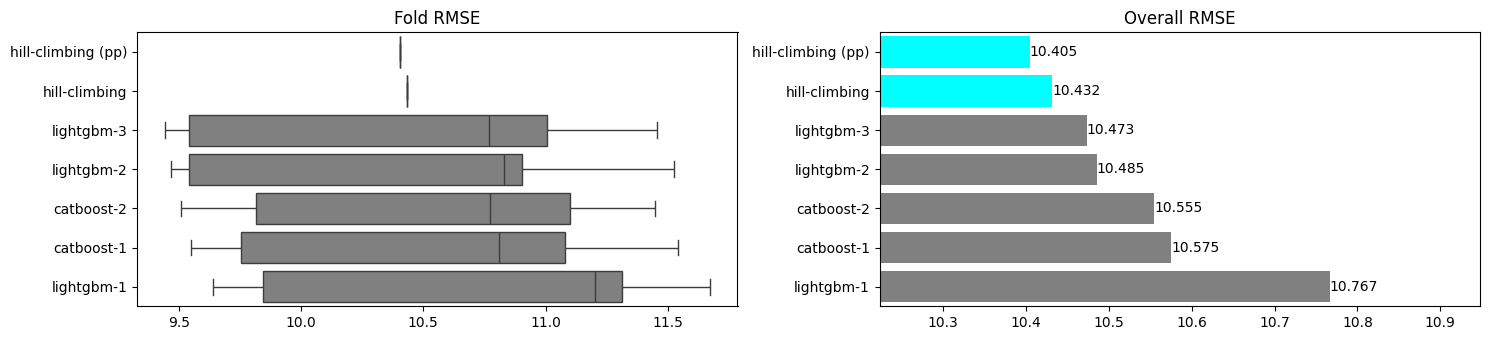

In [16]:
fold_scores_df = pd.DataFrame(fold_scores)
overall_scores_df = pd.DataFrame({k: [v] for k, v in overall_scores.items()}).transpose().sort_values(by=0, ascending=True)
order = overall_scores_df.index.tolist()

min_score = overall_scores_df.values.flatten().min()
max_score = overall_scores_df.values.flatten().max()
padding = (max_score - min_score) * 0.5
lower_limit = min_score - padding
upper_limit = max_score + padding

fig, axs = plt.subplots(1, 2, figsize=(15, fold_scores_df.shape[1] * 0.5))

boxplot = sns.boxplot(data=fold_scores_df, order=order, ax=axs[0], orient="h", color="grey")
axs[0].set_title(f"Fold RMSE")
axs[0].set_xlabel("")
axs[0].set_ylabel("")

barplot = sns.barplot(x=overall_scores_df.values.flatten(), y=overall_scores_df.index, ax=axs[1], color="grey")
axs[1].set_title(f"Overall RMSE")
axs[1].set_xlabel("")
axs[1].set_xlim(left=lower_limit, right=upper_limit)
axs[1].set_ylabel("")

for i, (score, model) in enumerate(zip(overall_scores_df.values.flatten(), overall_scores_df.index)):
    color = "cyan" if "hill" in model.lower() else "grey"
    barplot.patches[i].set_facecolor(color)
    boxplot.patches[i].set_facecolor(color)
    barplot.text(score, i, round(score, 3), va="center")

plt.tight_layout()
plt.show()